# Fase 2: Cuaterniones, QFT, características y etiquetado

Continúa desde `entregable_fase1.ipynb` — reutiliza `imagen`, `mascara` y `regiones_sp` ya cargados/calculados ahí. Corre primero esas celdas (o copia las de setup abajo) antes de seguir.

### Setup (si corres este notebook por separado)

In [ ]:
import sys; sys.path.append('..')

from src.io_utils import cargar_imagen, cargar_mascara, listar_pares_imagen_mascara
from src.presegmentation import presegmentar_superpixeles
from src.quaternion_qft import rgb_a_cuaternion, procesar_qft_superpixeles
from src.feature_extraction import (
    calcular_magnitud_espectral,
    extraer_matriz_caracteristicas,
    normalizar_caracteristicas,
)

import numpy as np
import matplotlib.pyplot as plt

In [112]:
pares = listar_pares_imagen_mascara('../data/raw/train', '../data/masks/train')
ruta_img, ruta_mask = pares[0]
imagen = cargar_imagen(ruta_img)
mascara = cargar_mascara(ruta_mask)

K_SEGMENTOS = 85
# m ∈ [1,40]-> importancia relativa entre similitud de color (↓) y proximidad espacial (↑)
M = 30

regiones_sp = presegmentar_superpixeles(imagen, n_segmentos=K_SEGMENTOS, m=M, num_iters=10)


etiquetas = np.zeros(imagen.shape[:2], dtype=int)
for i, region in enumerate(regiones_sp):
    etiquetas[region] = i

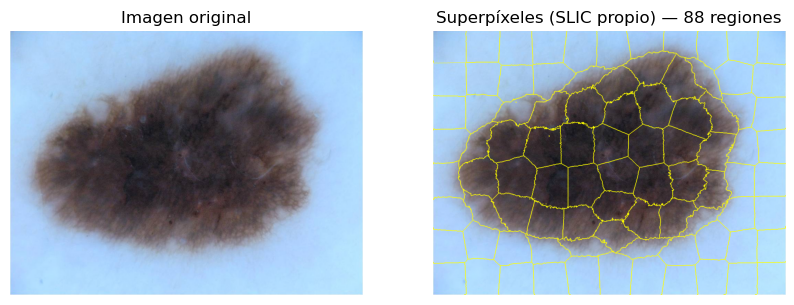

In [113]:
from skimage.segmentation import mark_boundaries

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(imagen)
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(mark_boundaries(imagen, etiquetas))
axes[1].set_title(f'Superpíxeles (SLIC propio) — {len(regiones_sp)} regiones')
axes[1].axis('off')

plt.show()

## Representación cuaterniónica

Convierte la imagen completa a cuaterniones puros $q = 0 + Ri + Gj + Bk$.

In [114]:
q_img = rgb_a_cuaternion(imagen)
print("Forma:", q_img.shape)       # (H, W, 4)
print("Parte real (w) siempre 0:", np.all(q_img[:, :, 0] == 0))
print("Un pixel de ejemplo (w,x,y,z):", q_img[100, 100])

Forma: (767, 1022, 4)
Parte real (w) siempre 0: True
Un pixel de ejemplo (w,x,y,z): [0.         0.67843137 0.84313725 0.99215686]


## QFT por superpíxel

Aplica la QFT 2D (ecuaciones 5, 6 y 10 del paper) sobre cada región de `regiones_sp`.

In [115]:
espectros_qft = procesar_qft_superpixeles(imagen, regiones_sp)

print("Superpíxeles con espectro calculado:", len(espectros_qft))
print("Forma del primer espectro F_k:", espectros_qft[0].shape)   # (M_k, N_k, 4)
print("dtype:", espectros_qft[0].dtype)                            # float64 (real, no complejo)

Superpíxeles con espectro calculado: 88
Forma del primer espectro F_k: (97, 96, 4)
dtype: float64


### Visualizar la magnitud espectral de un superpíxel

$|q| = \sqrt{R^2+I^2+J^2+K^2}$

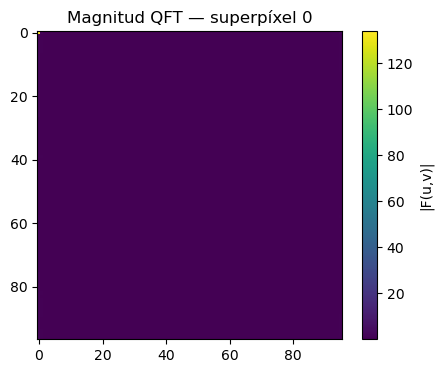

In [116]:
idx = 0
mag = calcular_magnitud_espectral(espectros_qft[idx])

plt.figure(figsize=(5, 4))
plt.imshow(mag, cmap='viridis')
plt.colorbar(label='|F(u,v)|')
plt.title(f'Magnitud QFT — superpíxel {idx}')
plt.show()

## Extracción y normalización de características

Vector por superpíxel: `[media_mag, std_mag, max_mag, energia, entropia]`.

In [117]:
X = extraer_matriz_caracteristicas(espectros_qft)
print("Forma de X (K superpíxeles x F características):", X.shape)

X_norm = normalizar_caracteristicas(X, metodo='zscore')
X_norm[:5]

Forma de X (K superpíxeles x F características): (88, 5)


array([[ 0.05783746,  1.49935259,  1.53670479,  1.61449769, -1.93612548],
       [ 0.32838344,  1.44533419,  1.46388182,  1.53147508, -1.45832805],
       [ 0.54246544,  1.49433098,  1.63070146,  1.61481342, -1.70631073],
       [ 1.04134959,  1.31524184,  1.37636873,  1.34119884, -1.19129704],
       [ 1.33215877,  1.18826169,  1.44092432,  1.15666863, -1.04391904]])

## Etiquetado (asignación de clase) — exploración

Aún no está en `src/`. Antes de formalizarlo, probamos aquí la lógica: para cada superpíxel, calculamos qué fracción de sus píxeles cae dentro de la máscara ground-truth (lesión). Si supera un **umbral**, se etiqueta como clase 1 (lesión); si no, clase 0 (piel sana).

La decisión de diseño a tomar es justamente ese umbral — un superpíxel que toca apenas el borde de la lesión, ¿cuenta como lesión o no?

In [118]:
def etiquetar_superpixeles(regiones_sp, mascara, umbral=0.5):
    """
    Asigna clase 0/1 a cada superpíxel según la fracción de sus píxeles
    que cae dentro de la máscara ground-truth (mascara > 0 = lesión).
    """
    mascara_bool = mascara > 0
    etiquetas_clase = []
    for region in regiones_sp:
        total = region.sum()
        positivos = np.logical_and(region, mascara_bool).sum()
        fraccion = positivos / total if total > 0 else 0.0
        etiquetas_clase.append(1 if fraccion >= umbral else 0)
    return np.array(etiquetas_clase)

UMBRAL = 0.9

y = etiquetar_superpixeles(regiones_sp, mascara, umbral=UMBRAL)
print("Forma de y:", y.shape)
print("Clase 0 (piel sana):", np.sum(y == 0), " | Clase 1 (lesión):", np.sum(y == 1))

Forma de y: (88,)
Clase 0 (piel sana): 53  | Clase 1 (lesión): 35


### ¿Cómo cambia la distribución de clases según el umbral?

In [119]:
for u in [0.1, 0.3, 0.5, 0.7, 0.9]:
    y_u = etiquetar_superpixeles(regiones_sp, mascara, umbral=u)
    print(f"umbral={u:.1f}  ->  clase 0: {np.sum(y_u == 0):3d}   clase 1: {np.sum(y_u == 1):3d}")

umbral=0.1  ->  clase 0:  37   clase 1:  51
umbral=0.3  ->  clase 0:  49   clase 1:  39
umbral=0.5  ->  clase 0:  49   clase 1:  39
umbral=0.7  ->  clase 0:  51   clase 1:  37
umbral=0.9  ->  clase 0:  53   clase 1:  35


### Visualizar el etiquetado sobre la imagen

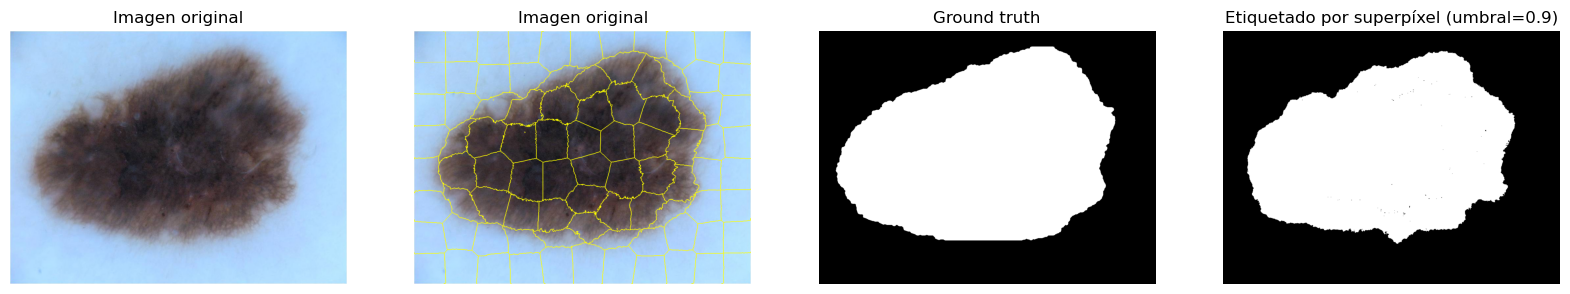

In [120]:
mapa_clases = np.zeros(imagen.shape[:2])
for i, region in enumerate(regiones_sp):
    mapa_clases[region] = y[i]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(imagen); axes[0].set_title('Imagen original'); axes[0].axis('off')


axes[1].imshow(imagen); axes[1].set_title('Imagen original'); axes[1].axis('off')
axes[1].imshow(mark_boundaries(imagen, etiquetas))

axes[2].imshow(mascara, cmap='gray'); axes[2].set_title('Ground truth'); axes[2].axis('off')
axes[3].imshow(mapa_clases, cmap='gray'); axes[3].set_title(f'Etiquetado por superpíxel (umbral={UMBRAL})'); axes[3].axis('off')
plt.show()

## Siguiente paso

Con `X_norm` (características normalizadas) y `y` (etiquetas por superpíxel) ya están listos los insumos para entrenar el clasificador (SVM / KNN / Random Forest).